# Data Analysis

In [3]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv('saudi-hourly-weather-data_Historical.csv')


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9270697 entries, 0 to 9270696
Data columns (total 36 columns):
 #   Column                                  Dtype  
---  ------                                  -----  
 0   ID                                      int64  
 1   STATION_ID                              int64  
 2   STATION_NAME                            object 
 3   STATION_COUNTRY                         object 
 4   OBSERVATION_DATE                        object 
 5   SOURCE_ID                               int64  
 6   LATITUDE                                float64
 7   LONGITUDE                               float64
 8   ELEVATION                               float64
 9   WIND_DIRECTION_ANGLE                    float64
 10  WIND_DIRECTION_ANGLE_UNITS              object 
 11  WIND_DIRECTION_QUALITY                  object 
 12  WIND_TYPE                               object 
 13  WIND_SPEED_RATE                         float64
 14  WIND_SPEED_RATE_UNITS             

In [54]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

df['STATION_NAME'].value_counts()


STATION_NAME
KING ABDULAZIZ AB                541660
PRINCE MOHAMMAD BIN ABDULAZIZ    402639
TABUK                            359217
QAISUMAH                         354324
WEJH                             349735
                                  ...  
WADI AL-DAWASSER                      1
AL-QATIF-GOSP-3                       1
AL-HOAGE                              1
ZULM                                  1
MASHTHOBAH                            1
Name: count, Length: 88, dtype: int64

# Data Cleaning

In [55]:
df['OBSERVATION_DATE'] = pd.to_datetime(df['OBSERVATION_DATE'])
df = df.drop('LAST_LOAD_DATE', axis=1)

In [56]:

df['WIND_DIRECTION_ANGLE'] = df['WIND_DIRECTION_ANGLE'].astype(float)
df.loc[(df['WIND_DIRECTION_ANGLE']>360) | (df['WIND_DIRECTION_ANGLE']<0), 'WIND_DIRECTION_ANGLE'] = np.nan

df.loc[df['WIND_TYPE']=='Missing', 'WIND_TYPE'] = np.nan

df['WIND_SPEED_RATE_RAW'] = df['WIND_SPEED_RATE']
df['WIND_SPEED_RATE'] = df['WIND_SPEED_RATE'].astype(float)
df.loc[df['WIND_SPEED_RATE']>=100, 'WIND_SPEED_RATE'] = np.nan

df['SKY_CEILING_HEIGHT_RAW'] = df['SKY_CEILING_HEIGHT']
df['SKY_CEILING_HEIGHT'] = df['SKY_CEILING_HEIGHT'].astype(float)
df.loc[df['SKY_CEILING_HEIGHT']>3700, 'SKY_CEILING_HEIGHT'] = np.nan
df['SKY_CEILING_PRESENT'] = df['SKY_CEILING_HEIGHT'].notna().map({True: 'yes', False: 'no'})


df['VISIBILITY_DISTANCE'] = df['VISIBILITY_DISTANCE'].astype(float)
df.loc[df['VISIBILITY_DISTANCE']>10000, 'VISIBILITY_DISTANCE'] = np.nan
df['VISIBILITY_PRESENT'] = df['VISIBILITY_DISTANCE'].notna().map({True: 'yes', False: 'no'})

df.loc[df['AIR_TEMPERATURE']>=99, 'AIR_TEMPERATURE'] = np.nan

df.loc[(df['AIR_TEMPERATURE_DEW_POINT']>=35) | (df['AIR_TEMPERATURE_DEW_POINT']<=-60), 'AIR_TEMPERATURE_DEW_POINT'] = np.nan


df['ATMOSPHERIC_SEA_LEVEL_PRESSURE'] = pd.to_numeric(df['ATMOSPHERIC_SEA_LEVEL_PRESSURE'], errors = 'coerce')
df.loc[(df['ATMOSPHERIC_SEA_LEVEL_PRESSURE'] < 870) | 
       (df['ATMOSPHERIC_SEA_LEVEL_PRESSURE'] > 1080), 
       'ATMOSPHERIC_SEA_LEVEL_PRESSURE'] = np.nan





In [57]:
df['VISIBILITY_PRESENT'].unique()

array(['yes', 'no'], dtype=object)

In [58]:
df.isna().mean().sort_values()


ID                                       0.00
SKY_CEILING_PRESENT                      0.00
SKY_CAVOK                                0.00
VISIBILITY_DISTANCE_UNITS                0.00
VISIBILITY_DISTANCE_QUALITY              0.00
VISIBILITY_VARIABILITY                   0.00
VISIBILITY_VARIABILITY_QUALITY           0.00
SKY_CEILING_QUALITY                      0.00
AIR_TEMPERATURE_UNITS                    0.00
AIR_TEMPERATURE_DEW_POINT_UNITS          0.00
AIR_TEMPERATURE_DEW_POINT_QUALITY        0.00
ATMOSPHERIC_SEA_LEVEL_PRESSURE_UNITS     0.00
ATMOSPHERIC_SEA_LEVEL_PRESSURE_QUALITY   0.00
WIND_SPEED_RATE_RAW                      0.00
SKY_CEILING_HEIGHT_RAW                   0.00
AIR_TEMPERATURE_QUALITY                  0.00
SKY_CEILING_HEIGHT_UNITS                 0.00
SKY_CEILING_DETERMINATION                0.00
WIND_SPEED_QUALITY                       0.00
STATION_ID                               0.00
STATION_NAME                             0.00
STATION_COUNTRY                   

In [59]:
missing_by_station = df.groupby('STATION_ID').agg(lambda x: x.isna().mean())
missing_by_station


,ID,STATION_NAME,STATION_COUNTRY,OBSERVATION_DATE,SOURCE_ID,LATITUDE,LONGITUDE,ELEVATION,WIND_DIRECTION_ANGLE,WIND_DIRECTION_ANGLE_UNITS,WIND_DIRECTION_QUALITY,WIND_TYPE,WIND_SPEED_RATE,WIND_SPEED_RATE_UNITS,WIND_SPEED_QUALITY,SKY_CEILING_HEIGHT,SKY_CEILING_HEIGHT_UNITS,SKY_CEILING_QUALITY,SKY_CEILING_DETERMINATION,SKY_CAVOK,VISIBILITY_DISTANCE,VISIBILITY_DISTANCE_UNITS,VISIBILITY_DISTANCE_QUALITY,VISIBILITY_VARIABILITY,VISIBILITY_VARIABILITY_QUALITY,AIR_TEMPERATURE,AIR_TEMPERATURE_UNITS,AIR_TEMPERATURE_QUALITY,AIR_TEMPERATURE_DEW_POINT,AIR_TEMPERATURE_DEW_POINT_UNITS,AIR_TEMPERATURE_DEW_POINT_QUALITY,ATMOSPHERIC_SEA_LEVEL_PRESSURE,ATMOSPHERIC_SEA_LEVEL_PRESSURE_UNITS,ATMOSPHERIC_SEA_LEVEL_PRESSURE_QUALITY,WIND_SPEED_RATE_RAW,SKY_CEILING_HEIGHT_RAW,SKY_CEILING_PRESENT,VISIBILITY_PRESENT
STATION_ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
40341599999,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.12,0.00,0.00,0.00,0.00,0.00,0.00,0.94,0.00,0.00,0.00,0.00,0.12,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
40356099999,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.08,0.00,0.00,0.02,0.02,0.00,0.00,0.90,0.00,0.00,0.00,0.00,0.26,0.00,0.00,0.00,0.00,0.02,0.00,0.00,0.02,0.00,0.00,0.91,0.00,0.00,0.00,0.00,0.00,0.00
40357099999,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.08,0.00,0.00,0.01,0.01,0.00,0.00,0.91,0.00,0.00,0.00,0.00,0.34,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.02,0.00,0.00,0.62,0.00,0.00,0.00,0.00,0.00,0.00
40358499999,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.17,0.00,0.00,0.09,0.09,0.00,0.00,0.93,0.00,0.00,0.00,0.00,0.11,0.00,0.00,0.00,0.00,0.05,0.00,0.00,0.06,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
40360099999,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.12,0.00,0.00,0.04,0.05,0.00,0.00,0.92,0.00,0.00,0.00,0.00,0.10,0.00,0.00,0.00,0.00,0.04,0.00,0.00,0.05,0.00,0.00,0.67,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41136099999,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.17,0.00,0.00,0.01,0.01,0.00,0.00,0.96,0.00,0.00,0.00,0.00,0.20,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.03,0.00,0.00,0.65,0.00,0.00,0.00,0.00,0.00,0.00
41136399999,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.15,0.00,0.00,0.09,0.09,0.00,0.00,0.94,0.00,0.00,0.00,0.00,0.06,0.00,0.00,0.00,0.00,0.04,0.00,0.00,0.06,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
41140099999,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.19,0.00,0.00,0.02,0.02,0.00,0.00,0.91,0.00,0.00,0.00,0.00,0.30,0.00,0.00,0.00,0.00,0.02,0.00,0.00,0.02,0.00,0.00,0.51,0.00,0.00,0.00,0.00,0.00,0.00


<Axes: ylabel='STATION_ID'>

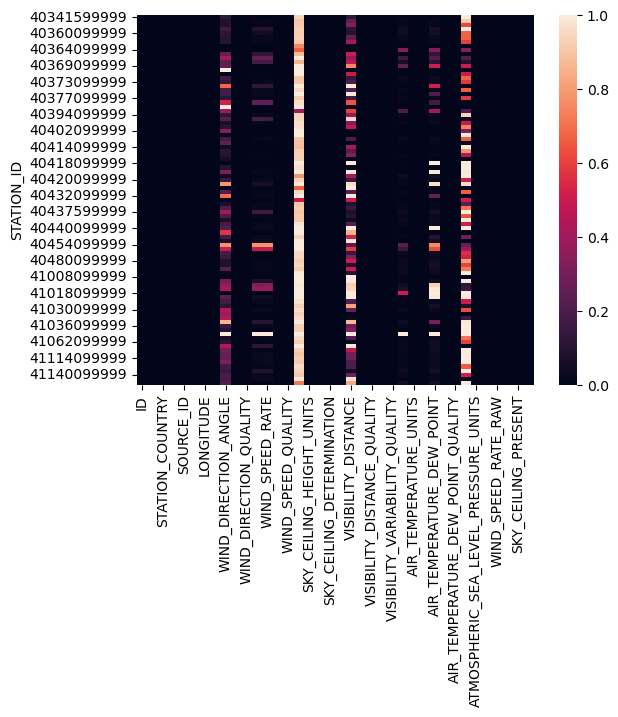

In [60]:
import seaborn as sns
sns.heatmap(missing_by_station)


In [61]:
essential = [
    'AIR_TEMPERATURE',
    'AIR_TEMPERATURE_DEW_POINT',
    'ATMOSPHERIC_SEA_LEVEL_PRESSURE',
    'WIND_SPEED_RATE'
    # (optionally add VISIBILITY_DISTANCE if you want)
]

high_quality_stations = missing_by_station[essential].max(axis=1) < 0.40
high_quality_station_ids = high_quality_stations[high_quality_stations].index
df_high_quality = df[df['STATION_ID'].isin(high_quality_station_ids)].copy()


In [62]:
len(high_quality_station_ids)


25

In [63]:
stations = df_high_quality['STATION_ID'].unique()
stations

array([40435099999, 40381099999, 40380099999, 40445099999, 40450099999,
       41080099999, 40363099999, 41032099999, 40422099999, 41141099999,
       40395099999, 41026099999, 40364099999, 40417099999, 40441099999,
       40410099999, 40366099999, 40370099999, 41031099999, 40367099999,
       40402099999, 40368099999, 40376099999, 40432099999, 41008099999])

In [64]:
df_high_quality.info()

<class 'pandas.core.frame.DataFrame'>
Index: 165580 entries, 960512 to 9165120
Data columns (total 39 columns):
 #   Column                                  Non-Null Count   Dtype         
---  ------                                  --------------   -----         
 0   ID                                      165580 non-null  int64         
 1   STATION_ID                              165580 non-null  int64         
 2   STATION_NAME                            165580 non-null  object        
 3   STATION_COUNTRY                         165580 non-null  object        
 4   OBSERVATION_DATE                        165580 non-null  datetime64[ns]
 5   SOURCE_ID                               165580 non-null  int64         
 6   LATITUDE                                165580 non-null  float64       
 7   LONGITUDE                               165580 non-null  float64       
 8   ELEVATION                               165580 non-null  float64       
 9   WIND_DIRECTION_ANGLE                

In [65]:
df_high_quality.head()

,ID,STATION_ID,STATION_NAME,STATION_COUNTRY,OBSERVATION_DATE,SOURCE_ID,LATITUDE,LONGITUDE,ELEVATION,WIND_DIRECTION_ANGLE,WIND_DIRECTION_ANGLE_UNITS,WIND_DIRECTION_QUALITY,WIND_TYPE,WIND_SPEED_RATE,WIND_SPEED_RATE_UNITS,WIND_SPEED_QUALITY,SKY_CEILING_HEIGHT,SKY_CEILING_HEIGHT_UNITS,SKY_CEILING_QUALITY,SKY_CEILING_DETERMINATION,SKY_CAVOK,VISIBILITY_DISTANCE,VISIBILITY_DISTANCE_UNITS,VISIBILITY_DISTANCE_QUALITY,VISIBILITY_VARIABILITY,VISIBILITY_VARIABILITY_QUALITY,AIR_TEMPERATURE,AIR_TEMPERATURE_UNITS,AIR_TEMPERATURE_QUALITY,AIR_TEMPERATURE_DEW_POINT,AIR_TEMPERATURE_DEW_POINT_UNITS,AIR_TEMPERATURE_DEW_POINT_QUALITY,ATMOSPHERIC_SEA_LEVEL_PRESSURE,ATMOSPHERIC_SEA_LEVEL_PRESSURE_UNITS,ATMOSPHERIC_SEA_LEVEL_PRESSURE_QUALITY,WIND_SPEED_RATE_RAW,SKY_CEILING_HEIGHT_RAW,SKY_CEILING_PRESENT,VISIBILITY_PRESENT
960512,960513,40435099999,AL-DAWADAMI,SA,1981-10-02 12:00:00,4,26.98,44.12,923.00,330.00,ANGULAR DEGREES,Passed all quality control checks,Normal,3.00,METERS PER SECOND,Passed all quality control checks,NaN,METERS,Passed all quality control checks,Statistically derived,No,NaN,METERS,Passed all quality control checks,Not variable,Passed gross limits check if element is present,39.00,DEGREES CELSIUS,Passed all quality control checks,-4.00,DEGREES CELSIUS,Passed all quality control checks,1002.10,HECTOPASCALS,Passed all quality control checks,3.00,22000.00,no,no
960513,960514,40435099999,AL-DAWADAMI,SA,1981-11-14 21:00:00,4,26.98,44.12,923.00,NaN,ANGULAR DEGREES,Passed all quality control checks,Calm,0.00,METERS PER SECOND,Passed all quality control checks,NaN,METERS,Passed all quality control checks,Statistically derived,No,NaN,METERS,Passed all quality control checks,Not variable,Passed gross limits check if element is present,23.00,DEGREES CELSIUS,Passed all quality control checks,16.00,DEGREES CELSIUS,Passed all quality control checks,1013.70,HECTOPASCALS,Passed all quality control checks,0.00,22000.00,no,no
960514,960515,40435099999,AL-DAWADAMI,SA,1981-11-26 09:00:00,4,26.98,44.12,923.00,270.00,ANGULAR DEGREES,Passed all quality control checks,Normal,2.50,METERS PER SECOND,Passed all quality control checks,NaN,METERS,Passed all quality control checks,Statistically derived,No,NaN,METERS,Passed all quality control checks,Not variable,Passed gross limits check if element is present,NaN,DEGREES CELSIUS,Passed gross limits check if element is present,NaN,DEGREES CELSIUS,Passed gross limits check if element is present,1012.10,HECTOPASCALS,Passed all quality control checks,2.50,22000.00,no,no
960515,960516,40435099999,AL-DAWADAMI,SA,1981-11-30 09:00:00,4,26.98,44.12,923.00,90.00,ANGULAR DEGREES,Passed all quality control checks,Normal,9.20,METERS PER SECOND,Passed all quality control checks,NaN,METERS,Passed all quality control checks,Statistically derived,No,7000.00,METERS,Passed all quality control checks,Not variable,Passed gross limits check if element is present,22.00,DEGREES CELSIUS,Passed all quality control checks,-1.00,DEGREES CELSIUS,Passed all quality control checks,1017.80,HECTOPASCALS,Passed all quality control checks,9.20,22000.00,no,yes
960516,960517,40435099999,AL-DAWADAMI,SA,1981-11-30 15:00:00,4,26.98,44.12,923.00,330.00,ANGULAR DEGREES,Passed all quality control checks,Normal,2.00,METERS PER SECOND,Passed all quality control checks,NaN,METERS,Passed all quality control checks,Statistically derived,No,NaN,METERS,Passed all quality control checks,Not variable,Passed gross limits check if element is present,28.00,DEGREES CELSIUS,Passed all quality control checks,19.00,DEGREES CELSIUS,Suspect,1013.10,HECTOPASCALS,Passed all quality control checks,2.00,22000.00,no,no


In [66]:
df_high_quality['VISIBILITY_PRESENT'].unique()

array(['no', 'yes'], dtype=object)

In [67]:

df_high_quality['VISIBILITY_PRESENT'].value_counts()


VISIBILITY_PRESENT
yes    91223
no     74357
Name: count, dtype: int64

In [68]:
df_high_quality['SKY_CEILING_PRESENT'].unique()

array(['no', 'yes'], dtype=object)

In [69]:
df_high_quality['SKY_CEILING_PRESENT'] = df_high_quality['SKY_CEILING_PRESENT'].map({'yes': 1, 'no':0})
df_high_quality['VISIBILITY_PRESENT'] = df_high_quality['VISIBILITY_PRESENT'].map({'yes': 1, 'no':0})

In [70]:
df_high_quality.to_csv('weather_data_hq.csv', index=False)


# Feature Engineering

In [71]:
df_high_quality.head()

,ID,STATION_ID,STATION_NAME,STATION_COUNTRY,OBSERVATION_DATE,SOURCE_ID,LATITUDE,LONGITUDE,ELEVATION,WIND_DIRECTION_ANGLE,WIND_DIRECTION_ANGLE_UNITS,WIND_DIRECTION_QUALITY,WIND_TYPE,WIND_SPEED_RATE,WIND_SPEED_RATE_UNITS,WIND_SPEED_QUALITY,SKY_CEILING_HEIGHT,SKY_CEILING_HEIGHT_UNITS,SKY_CEILING_QUALITY,SKY_CEILING_DETERMINATION,SKY_CAVOK,VISIBILITY_DISTANCE,VISIBILITY_DISTANCE_UNITS,VISIBILITY_DISTANCE_QUALITY,VISIBILITY_VARIABILITY,VISIBILITY_VARIABILITY_QUALITY,AIR_TEMPERATURE,AIR_TEMPERATURE_UNITS,AIR_TEMPERATURE_QUALITY,AIR_TEMPERATURE_DEW_POINT,AIR_TEMPERATURE_DEW_POINT_UNITS,AIR_TEMPERATURE_DEW_POINT_QUALITY,ATMOSPHERIC_SEA_LEVEL_PRESSURE,ATMOSPHERIC_SEA_LEVEL_PRESSURE_UNITS,ATMOSPHERIC_SEA_LEVEL_PRESSURE_QUALITY,WIND_SPEED_RATE_RAW,SKY_CEILING_HEIGHT_RAW,SKY_CEILING_PRESENT,VISIBILITY_PRESENT
960512,960513,40435099999,AL-DAWADAMI,SA,1981-10-02 12:00:00,4,26.98,44.12,923.00,330.00,ANGULAR DEGREES,Passed all quality control checks,Normal,3.00,METERS PER SECOND,Passed all quality control checks,NaN,METERS,Passed all quality control checks,Statistically derived,No,NaN,METERS,Passed all quality control checks,Not variable,Passed gross limits check if element is present,39.00,DEGREES CELSIUS,Passed all quality control checks,-4.00,DEGREES CELSIUS,Passed all quality control checks,1002.10,HECTOPASCALS,Passed all quality control checks,3.00,22000.00,0,0
960513,960514,40435099999,AL-DAWADAMI,SA,1981-11-14 21:00:00,4,26.98,44.12,923.00,NaN,ANGULAR DEGREES,Passed all quality control checks,Calm,0.00,METERS PER SECOND,Passed all quality control checks,NaN,METERS,Passed all quality control checks,Statistically derived,No,NaN,METERS,Passed all quality control checks,Not variable,Passed gross limits check if element is present,23.00,DEGREES CELSIUS,Passed all quality control checks,16.00,DEGREES CELSIUS,Passed all quality control checks,1013.70,HECTOPASCALS,Passed all quality control checks,0.00,22000.00,0,0
960514,960515,40435099999,AL-DAWADAMI,SA,1981-11-26 09:00:00,4,26.98,44.12,923.00,270.00,ANGULAR DEGREES,Passed all quality control checks,Normal,2.50,METERS PER SECOND,Passed all quality control checks,NaN,METERS,Passed all quality control checks,Statistically derived,No,NaN,METERS,Passed all quality control checks,Not variable,Passed gross limits check if element is present,NaN,DEGREES CELSIUS,Passed gross limits check if element is present,NaN,DEGREES CELSIUS,Passed gross limits check if element is present,1012.10,HECTOPASCALS,Passed all quality control checks,2.50,22000.00,0,0
960515,960516,40435099999,AL-DAWADAMI,SA,1981-11-30 09:00:00,4,26.98,44.12,923.00,90.00,ANGULAR DEGREES,Passed all quality control checks,Normal,9.20,METERS PER SECOND,Passed all quality control checks,NaN,METERS,Passed all quality control checks,Statistically derived,No,7000.00,METERS,Passed all quality control checks,Not variable,Passed gross limits check if element is present,22.00,DEGREES CELSIUS,Passed all quality control checks,-1.00,DEGREES CELSIUS,Passed all quality control checks,1017.80,HECTOPASCALS,Passed all quality control checks,9.20,22000.00,0,1
960516,960517,40435099999,AL-DAWADAMI,SA,1981-11-30 15:00:00,4,26.98,44.12,923.00,330.00,ANGULAR DEGREES,Passed all quality control checks,Normal,2.00,METERS PER SECOND,Passed all quality control checks,NaN,METERS,Passed all quality control checks,Statistically derived,No,NaN,METERS,Passed all quality control checks,Not variable,Passed gross limits check if element is present,28.00,DEGREES CELSIUS,Passed all quality control checks,19.00,DEGREES CELSIUS,Suspect,1013.10,HECTOPASCALS,Passed all quality control checks,2.00,22000.00,0,0


In [72]:
# 1. List your continuous columns
continuous_cols = [
    'AIR_TEMPERATURE',
    'AIR_TEMPERATURE_DEW_POINT',
    'ATMOSPHERIC_SEA_LEVEL_PRESSURE',
    'WIND_SPEED_RATE'
]

# 2. Fill NaNs with station-wise mean
df_high_quality[continuous_cols] = (
    df_high_quality
    .groupby('STATION_ID')[continuous_cols]
    .transform(lambda x: x.fillna(x.mean()))
)

# 3. Optional: check remaining NaNs
print(df_high_quality[continuous_cols].isna().sum())


AIR_TEMPERATURE                   0
AIR_TEMPERATURE_DEW_POINT         0
ATMOSPHERIC_SEA_LEVEL_PRESSURE    0
WIND_SPEED_RATE                   0
dtype: int64


In [73]:
df_high_quality['WIND_DIRECTION_ANGLE'].unique()

array([330.,  nan, 270.,  90.,  30., 180., 250., 160., 210., 300., 290.,
       320.,  50., 310., 200., 220.,  60.,  40.,  10., 350., 170., 150.,
       260., 280., 230., 130., 190.,  70., 120., 110., 360., 140.,  20.,
       340., 100.,  80., 240.])

In [74]:
df_high_quality['SKY_CEILING_PRESENT'].unique()

array([0, 1])

In [75]:
import numpy as np

# 1) Temperature–dewpoint spread (°C)
df_high_quality['TEMP_DEW_SPREAD'] = (
    df_high_quality['AIR_TEMPERATURE'] - df_high_quality['AIR_TEMPERATURE_DEW_POINT']
)

# 2) Approximate Relative Humidity (%)
# Using Magnus formula; safe for typical surface temps.
T = df_high_quality['AIR_TEMPERATURE']
Td = df_high_quality['AIR_TEMPERATURE_DEW_POINT']

# Avoid weird NaNs or overflows by clipping temps to a reasonable range
T_clip = T.clip(-80, 60)
Td_clip = Td.clip(-80, 60)

es = 6.112 * np.exp((17.67 * T_clip) / (T_clip + 243.5))      # saturation vapor pressure
e  = 6.112 * np.exp((17.67 * Td_clip) / (Td_clip + 243.5))    # actual vapor pressure

RH = 100 * (e / es)
df_high_quality['RELATIVE_HUMIDITY'] = RH.clip(0, 100)

# 3) Wind components (U = zonal, V = meridional)
# Positive U = wind from west to east
# Positive V = wind from south to north
# Adjust column name below if your direction column is named differently.
missing_dir = df_high_quality['WIND_DIRECTION_ANGLE'].isna()
theta = np.deg2rad(df_high_quality['WIND_DIRECTION_ANGLE'].fillna(0))
df_high_quality['WIND_U'] = df_high_quality['WIND_SPEED_RATE'] * np.cos(theta)
df_high_quality['WIND_V'] = df_high_quality['WIND_SPEED_RATE'] * np.sin(theta)



# 4) Pressure tendency (change vs previous obs for same station)
# Sort first to ensure correct time order
df_high_quality = df_high_quality.sort_values(['STATION_ID', 'OBSERVATION_DATE'])

df_high_quality['PRESSURE_TENDENCY'] = (
    df_high_quality
    .groupby('STATION_ID')['ATMOSPHERIC_SEA_LEVEL_PRESSURE']
    .diff()
)
df_high_quality['PRESSURE_TENDENCY'] = df_high_quality['PRESSURE_TENDENCY'].fillna(0)



In [76]:
df_high_quality.head()

,ID,STATION_ID,STATION_NAME,STATION_COUNTRY,OBSERVATION_DATE,SOURCE_ID,LATITUDE,LONGITUDE,ELEVATION,WIND_DIRECTION_ANGLE,WIND_DIRECTION_ANGLE_UNITS,WIND_DIRECTION_QUALITY,WIND_TYPE,WIND_SPEED_RATE,WIND_SPEED_RATE_UNITS,WIND_SPEED_QUALITY,SKY_CEILING_HEIGHT,SKY_CEILING_HEIGHT_UNITS,SKY_CEILING_QUALITY,SKY_CEILING_DETERMINATION,SKY_CAVOK,VISIBILITY_DISTANCE,VISIBILITY_DISTANCE_UNITS,VISIBILITY_DISTANCE_QUALITY,VISIBILITY_VARIABILITY,VISIBILITY_VARIABILITY_QUALITY,AIR_TEMPERATURE,AIR_TEMPERATURE_UNITS,AIR_TEMPERATURE_QUALITY,AIR_TEMPERATURE_DEW_POINT,AIR_TEMPERATURE_DEW_POINT_UNITS,AIR_TEMPERATURE_DEW_POINT_QUALITY,ATMOSPHERIC_SEA_LEVEL_PRESSURE,ATMOSPHERIC_SEA_LEVEL_PRESSURE_UNITS,ATMOSPHERIC_SEA_LEVEL_PRESSURE_QUALITY,WIND_SPEED_RATE_RAW,SKY_CEILING_HEIGHT_RAW,SKY_CEILING_PRESENT,VISIBILITY_PRESENT,TEMP_DEW_SPREAD,RELATIVE_HUMIDITY,WIND_U,WIND_V,PRESSURE_TENDENCY
1043497,1043498,40363099999,AL-ZABERAH,SA,2017-04-19 18:00:00,4,28.00,41.45,617.00,270.00,ANGULAR DEGREES,Passed all quality control checks,Normal,1.50,METERS PER SECOND,Passed all quality control checks,NaN,METERS,Passed gross limits check if element is present,Missing,No,4000.00,METERS,Passed all quality control checks,Missing,Passed gross limits check if element is present,27.30,DEGREES CELSIUS,Passed all quality control checks,8.30,DEGREES CELSIUS,Passed all quality control checks,1007.80,HECTOPASCALS,Passed all quality control checks,1.50,99999.00,0,1,19.00,30.15,-0.00,-1.50,0.00
1043498,1043499,40363099999,AL-ZABERAH,SA,2017-06-05 21:00:00,4,28.00,41.45,617.00,270.00,ANGULAR DEGREES,Passed all quality control checks,Normal,0.50,METERS PER SECOND,Passed all quality control checks,1800.00,METERS,Passed all quality control checks,Statistically derived,No,4000.00,METERS,Passed all quality control checks,Missing,Passed gross limits check if element is present,25.60,DEGREES CELSIUS,Passed all quality control checks,20.90,DEGREES CELSIUS,Passed all quality control checks,1007.10,HECTOPASCALS,Passed all quality control checks,0.50,1800.00,1,1,4.70,75.26,-0.00,-0.50,-0.70
1043499,1043500,40363099999,AL-ZABERAH,SA,2017-06-06 00:00:00,4,28.00,41.45,617.00,270.00,ANGULAR DEGREES,Passed all quality control checks,Normal,0.50,METERS PER SECOND,Passed all quality control checks,NaN,METERS,Passed gross limits check if element is present,Missing,No,4000.00,METERS,Passed all quality control checks,Missing,Passed gross limits check if element is present,25.20,DEGREES CELSIUS,Passed all quality control checks,21.10,DEGREES CELSIUS,Passed all quality control checks,1007.30,HECTOPASCALS,Passed all quality control checks,0.50,99999.00,0,1,4.10,78.03,-0.00,-0.50,0.20
1043500,1043501,40363099999,AL-ZABERAH,SA,2017-07-05 06:00:00,4,28.00,41.45,617.00,270.00,ANGULAR DEGREES,Passed all quality control checks,Normal,3.10,METERS PER SECOND,Passed all quality control checks,NaN,METERS,Passed gross limits check if element is present,Missing,No,10000.00,METERS,Passed all quality control checks,Missing,Passed gross limits check if element is present,27.40,DEGREES CELSIUS,Passed all quality control checks,21.60,DEGREES CELSIUS,Passed all quality control checks,1005.90,HECTOPASCALS,Passed all quality control checks,3.10,99999.00,0,1,5.80,70.65,-0.00,-3.10,-1.40
2571854,2571855,40364099999,JUBBAH,SA,2002-05-18 12:00:00,4,28.03,40.95,945.00,310.00,ANGULAR DEGREES,Passed all quality control checks,Normal,22.00,METERS PER SECOND,Passed all quality control checks,NaN,METERS,Passed all quality control checks,Missing,No,9000.00,METERS,Passed all quality control checks,Not variable,Passed all quality control checks,29.00,DEGREES CELSIUS,Passed all quality control checks,8.00,DEGREES CELSIUS,Passed all quality control checks,1009.10,HECTOPASCALS,Passed all quality control checks,22.00,22000.00,0,1,21.00,26.76,14.14,-16.85,0.00


In [77]:
df_high_quality['SKY_CEILING_PRESENT'].unique()

array([0, 1])

In [78]:
df_high_quality['VISIBILITY_PRESENT'].unique()

array([1, 0])

In [79]:
from sklearn.preprocessing import StandardScaler

# Select the features you want to use for clustering
features_for_clustering = [
    'AIR_TEMPERATURE',
    'AIR_TEMPERATURE_DEW_POINT',
    'TEMP_DEW_SPREAD',
    'RELATIVE_HUMIDITY',
    'ATMOSPHERIC_SEA_LEVEL_PRESSURE',
    'PRESSURE_TENDENCY',
    'WIND_SPEED_RATE',
    'WIND_U',
    'WIND_V',
    'VISIBILITY_PRESENT',
    'SKY_CEILING_PRESENT'
]

# 1. Extract the feature matrix
X = df_high_quality[features_for_clustering]

# 2. Initialize the scaler
scaler = StandardScaler()

# 3. Fit and transform
X_scaled = scaler.fit_transform(X)

# 4. Convert back into DataFrame for convenience
X_scaled = pd.DataFrame(X_scaled, columns=features_for_clustering, index=df_high_quality.index)


# Frequent Pattern Mining

In [80]:
import pandas as pd

df_ap = pd.DataFrame()

# 🌫 Visibility Events
df_ap['LOW_VISIBILITY'] = df_high_quality['VISIBILITY_DISTANCE'] < 1000
df_ap['HIGH_VISIBILITY'] = df_high_quality['VISIBILITY_DISTANCE'] >= 1000

# 💧 Humidity Events
df_ap['HIGH_HUMIDITY'] = df_high_quality['RELATIVE_HUMIDITY'] > 80
df_ap['DRY_AIR'] = df_high_quality['RELATIVE_HUMIDITY'] < 40

# 🌁 Fog Likelihood
df_ap['FOG_LIKELY'] = df_high_quality['TEMP_DEW_SPREAD'] < 2

# ☁ Ceiling Events
df_ap['LOW_CEILING'] = df_high_quality['SKY_CEILING_PRESENT'] == 1
df_ap['NO_CEILING'] = df_high_quality['SKY_CEILING_PRESENT'] == 0

# 💨 Wind Events
df_ap['STRONG_WIND'] = df_high_quality['WIND_SPEED_RATE'] > 6
df_ap['CALM_WIND'] = df_high_quality['WIND_SPEED_RATE'] < 2

# ⬇ Pressure Events
df_ap['FALLING_PRESSURE'] = df_high_quality['PRESSURE_TENDENCY'] < 0
df_ap['RISING_PRESSURE'] = df_high_quality['PRESSURE_TENDENCY'] > 0

# Convert to boolean for Apriori
df_ap = df_ap.astype(bool)

from mlxtend.frequent_patterns import apriori, association_rules

# 1. Find frequent itemsets (support threshold can be tuned)
frequent_items = apriori(df_ap, min_support=0.05, use_colnames=True)

# 2. Generate association rules
rules = association_rules(frequent_items, metric="confidence", min_threshold=0.6)

# 3. Sort by lift (strongest associations first)
rules.sort_values("lift", ascending=False).head(20)


from mlxtend.frequent_patterns import apriori, association_rules
# Frequent itemsets with >= 75% support
frequent_items = apriori(df_ap, min_support=0.50, use_colnames=True)

# Strong rules with >= 75% confidence
rules = association_rules(
    frequent_items, 
    metric="confidence", 
    min_threshold=0.50
)

# Sort strongest rules first
strong_rules = rules.sort_values("lift", ascending=False)

strong_rules






,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
2,(NO_CEILING),(DRY_AIR),0.94,0.54,0.52,0.55,1.02,1.00,0.01,1.02,0.32,0.54,0.02,0.76
3,(DRY_AIR),(NO_CEILING),0.54,0.94,0.52,0.96,1.02,1.00,0.01,1.44,0.04,0.54,0.31,0.76
0,(NO_CEILING),(HIGH_VISIBILITY),0.94,0.55,0.50,0.53,0.98,1.00,-0.01,0.97,-0.27,0.51,-0.03,0.73
1,(HIGH_VISIBILITY),(NO_CEILING),0.55,0.94,0.50,0.92,0.98,1.00,-0.01,0.75,-0.05,0.51,-0.33,0.73


In [81]:
df_high_quality['SKY_CEILING_PRESENT'].unique()

array([0, 1])

In [82]:
df_high_quality['VISIBILITY_PRESENT'].unique()

array([1, 0])

In [83]:
df_high_quality[features_for_clustering].info()

<class 'pandas.core.frame.DataFrame'>
Index: 165580 entries, 1043497 to 1973453
Data columns (total 11 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   AIR_TEMPERATURE                 165580 non-null  float64
 1   AIR_TEMPERATURE_DEW_POINT       165580 non-null  float64
 2   TEMP_DEW_SPREAD                 165580 non-null  float64
 3   RELATIVE_HUMIDITY               165580 non-null  float64
 4   ATMOSPHERIC_SEA_LEVEL_PRESSURE  165580 non-null  float64
 5   PRESSURE_TENDENCY               165580 non-null  float64
 6   WIND_SPEED_RATE                 165580 non-null  float64
 7   WIND_U                          165580 non-null  float64
 8   WIND_V                          165580 non-null  float64
 9   VISIBILITY_PRESENT              165580 non-null  int64  
 10  SKY_CEILING_PRESENT             165580 non-null  int64  
dtypes: float64(9), int64(2)
memory usage: 15.2 MB


# Clustering

In [85]:
from sklearn.cluster import KMeans

# 1. Choose number of clusters
k = 4

# 2. Initialize KMeans
kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

# 3. Fit KMeans on your scaled features
kmeans.fit(X_scaled)

# 4. Add pattern labels to your DataFrame
df_high_quality['WEATHER_PATTERN'] = kmeans.labels_


In [86]:
df_high_quality['WEATHER_PATTERN'].value_counts()

WEATHER_PATTERN
0    74567
2    59553
1    21379
3    10081
Name: count, dtype: int64

In [87]:
cluster_centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=X_scaled.columns
)
cluster_centers


,AIR_TEMPERATURE,AIR_TEMPERATURE_DEW_POINT,TEMP_DEW_SPREAD,RELATIVE_HUMIDITY,ATMOSPHERIC_SEA_LEVEL_PRESSURE,PRESSURE_TENDENCY,WIND_SPEED_RATE,WIND_U,WIND_V,VISIBILITY_PRESENT,SKY_CEILING_PRESENT
0,-0.23,0.75,-0.83,0.86,0.40,0.08,-0.12,0.11,-0.11,-0.17,-0.25
1,-0.57,-1.40,0.91,-0.90,-2.29,-0.06,-0.37,-0.08,0.24,-1.10,-0.25
2,0.54,-0.47,0.78,-0.82,0.25,-0.08,0.22,-0.08,0.05,0.54,-0.25
3,-0.30,0.22,-0.39,0.40,0.42,0.01,0.42,-0.17,0.03,0.40,3.93


# # CLUSTER INTERPRETATION SUMMARY
#### 0 = Humid Stable Air Mass            → high RH, low spread, calm winds
#### 1 = Cold Dry Continental Air         → low temp/dewpoint, dry air, clear conditions
#### 2 = Warm Dry Transitional Air Mass   → warm, dry, breezy, good visibility
#### 3 = Low-Ceiling Stratiform Regime    → high ceiling_present, humid, breezy, overcast


In [88]:
# Mapping of cluster labels to meteorological names
pattern_names = {
    0: "Humid Stable Air Mass",
    1: "Cold Dry Continental Air",
    2: "Warm Dry Transitional Air Mass",
    3: "Low-Ceiling Stratiform Cloud Regime"
}

# Create a new column with readable names
df_high_quality['WEATHER_PATTERN_NAME'] = df_high_quality['WEATHER_PATTERN'].map(pattern_names)


In [89]:
df_high_quality['WEATHER_PATTERN_NAME'].value_counts()


WEATHER_PATTERN_NAME
Humid Stable Air Mass                  74567
Warm Dry Transitional Air Mass         59553
Cold Dry Continental Air               21379
Low-Ceiling Stratiform Cloud Regime    10081
Name: count, dtype: int64

# Classification

In [90]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd

# 1) Choose the features you want the classifier to use
feature_cols = [
    'AIR_TEMPERATURE',
    'AIR_TEMPERATURE_DEW_POINT',
    'TEMP_DEW_SPREAD',
    'RELATIVE_HUMIDITY',
    'ATMOSPHERIC_SEA_LEVEL_PRESSURE',
    'PRESSURE_TENDENCY',
    'WIND_SPEED_RATE',
    'WIND_U',
    'WIND_V',
    'VISIBILITY_PRESENT',
    'SKY_CEILING_PRESENT'
]

X = df_high_quality[feature_cols]
y = df_high_quality['WEATHER_PATTERN']   # numeric labels: 0,1,2,3

# 2) Train–test split (stratified to keep pattern proportions)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3) Build a pipeline: StandardScaler (optional but safe) + RandomForest
clf = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

# 4) Train the classifier
clf.fit(X_train, y_train)

# 5) Predict on test set
y_pred = clf.predict(X_test)

# 6) Evaluation
print("Classification report:")
print(classification_report(y_test, y_pred))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))


Classification report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     14913
           1       1.00      0.99      1.00      4276
           2       0.99      0.99      0.99     11911
           3       1.00      1.00      1.00      2016

    accuracy                           0.99     33116
   macro avg       1.00      1.00      1.00     33116
weighted avg       0.99      0.99      0.99     33116


Confusion matrix:
[[14844     8    61     0]
 [   10  4253    13     0]
 [   76    11 11824     0]
 [    0     0     0  2016]]


In [91]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

# -----------------------------------------
# 1. Extract original features and labels
# -----------------------------------------
feature_cols = [
    'AIR_TEMPERATURE',
    'AIR_TEMPERATURE_DEW_POINT',
    'TEMP_DEW_SPREAD',
    'RELATIVE_HUMIDITY',
    'ATMOSPHERIC_SEA_LEVEL_PRESSURE',
    'PRESSURE_TENDENCY',
    'WIND_SPEED_RATE',
    'WIND_U',
    'WIND_V',
    'VISIBILITY_PRESENT',
    'SKY_CEILING_PRESENT'
]

X = df_high_quality[feature_cols].reset_index(drop=True)
y = df_high_quality['WEATHER_PATTERN'].reset_index(drop=True)

# -----------------------------------------
# 2. SHUFFLE LABELS (real overfitting test)
# -----------------------------------------
y_shuffled = y.sample(frac=1, random_state=42).reset_index(drop=True)

# -----------------------------------------
# 3. Train-test split using shuffled labels
# -----------------------------------------
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X,
    y_shuffled,
    test_size=0.2,
    random_state=42,
    stratify=y_shuffled
)

# -----------------------------------------
# 4. Classification model (same pipeline)
# -----------------------------------------
clf_shuffled = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

clf_shuffled.fit(X_train_s, y_train_s)
y_pred_s = clf_shuffled.predict(X_test_s)

# -----------------------------------------
# 5. Evaluation
# -----------------------------------------
print("Classification report (SHUFFLED labels):\n")
print(classification_report(y_test_s, y_pred_s))

print("\nConfusion matrix:")
print(confusion_matrix(y_test_s, y_pred_s))


Classification report (SHUFFLED labels):

              precision    recall  f1-score   support

           0       0.45      0.68      0.55     14913
           1       0.12      0.01      0.02      4276
           2       0.37      0.31      0.34     11911
           3       0.02      0.00      0.00      2016

    accuracy                           0.42     33116
   macro avg       0.24      0.25      0.23     33116
weighted avg       0.35      0.42      0.37     33116


Confusion matrix:
[[10207   203  4466    37]
 [ 2934    57  1268    17]
 [ 7989   168  3725    29]
 [ 1394    35   585     2]]


# Knowledge

In [92]:
df_high_quality['STATION_NAME'].value_counts()

STATION_NAME
AL-DAWADAMI                                 30914
JEDDAH                                      25110
AL-KHARJ                                    20256
K.F.I.A. (KING FAHAD INT. AIRPORT) DAMMA    18210
ARAFAT                                      14184
KHAYBER                                     11702
UQLAT AL-SUQ0R                               7847
TAYMA                                        7653
AL-QUNFUDAH                                  7309
AL-KHAFJI                                    7198
AL-KHUSARIAH                                 5589
HAIL AIRPORT                                 3983
GIZAN                                        3368
MINA                                         2158
TAWQAH                                         49
QIBAH                                          19
LISS                                            8
KHASHM ALAN/ RIYADH AIRPORT                     7
AL-ZABERAH                                      4
DAMMAM - MET.                        

we had 88 stations in our original dataset. 
we had good mix of numerical and categorical values
we cleaned the features (transformed placeholder values to nan, mapped the binary class features into 0 and 1 )
we removed stations corresponding to more than 40 percentage of feature missing values. 
we did feature engineering (Added relative humidity, tempdew sepread etc, this makes the job easy for the models)
we used cluster to find out top 4 prominent weather charactersitics
we arrived at 4 prominent clusters (weather patterns)
we named each cluster with relevant names
we ran a classification model to classify the rows into classes(weather patterns)
f1 score turned out to be excellent
our classification model is now ready for deployment


Insight 1:
out of all 88 Stations, AL DAWADAMI and JEDDAH stand out as they produces Quality data at most number of instances, meaning they have well maintained data collection sensors. this is also a reasonable ingight because both these stations are located in prominent Region provinces in Saudi Arabia, Riyadh(Capital) and Makkah(Plgrims traffic). 

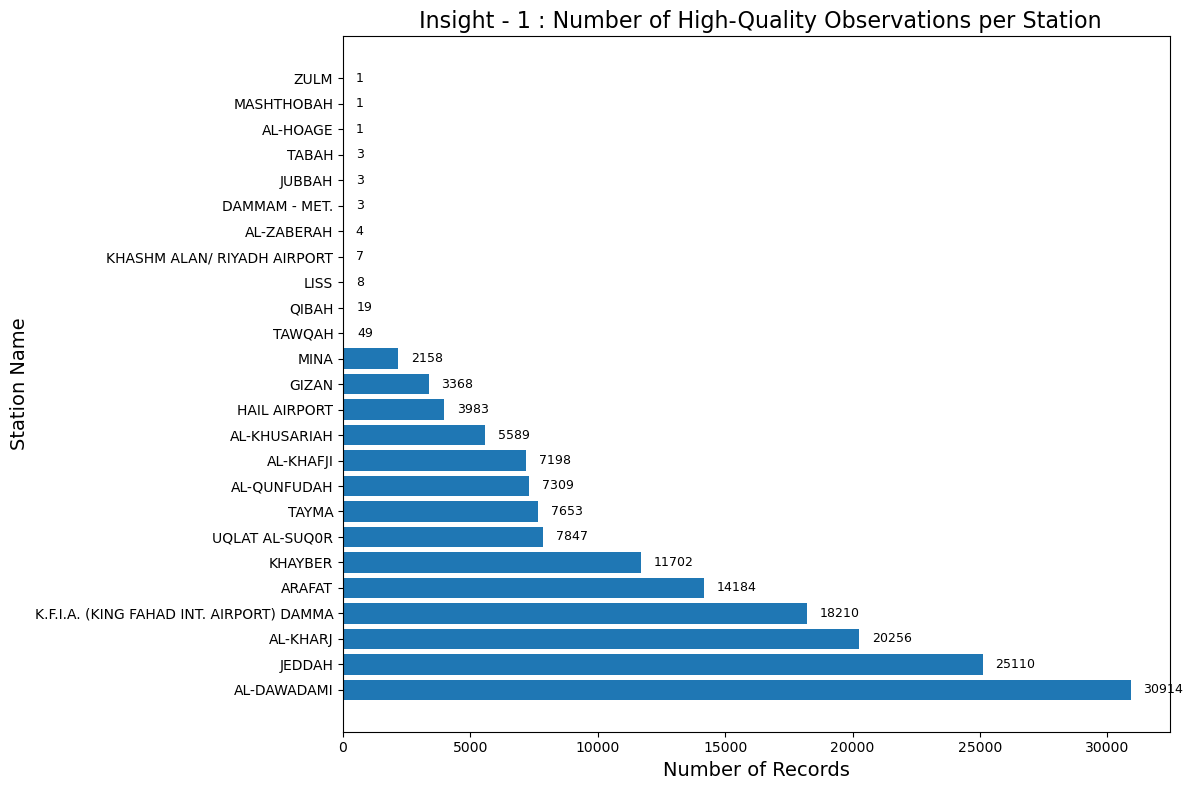

In [106]:
import matplotlib.pyplot as plt

# If you already have this Series, you can reuse it directly:
# station_counts = df_high_quality['STATION_NAME'].value_counts()

station_counts = df_high_quality['STATION_NAME'].value_counts()  # gives exactly what you printed

plt.figure(figsize=(12, 8))

# Horizontal bar chart
plt.barh(station_counts.index, station_counts.values)

plt.title(" Insight - 1 : Number of High-Quality Observations per Station", fontsize=16)
plt.xlabel("Number of Records", fontsize=14)
plt.ylabel("Station Name", fontsize=14)

plt.yticks(fontsize=10)
plt.xticks(fontsize=10)

# Optional: show counts on the bars
for i, v in enumerate(station_counts.values):
    plt.text(v + 500, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()


Insight 2: 
The Kingdom's Airport Weather Patterns revolve around 4 main categories,

Humid Stable Air Mass                  74567
Warm Dry Transitional Air Mass         59553
Cold Dry Continental Air               21379
Low-Ceiling Stratiform Cloud Regime    10081, 

Among which the Humid Stable Air Mass seems to be often occurring. 

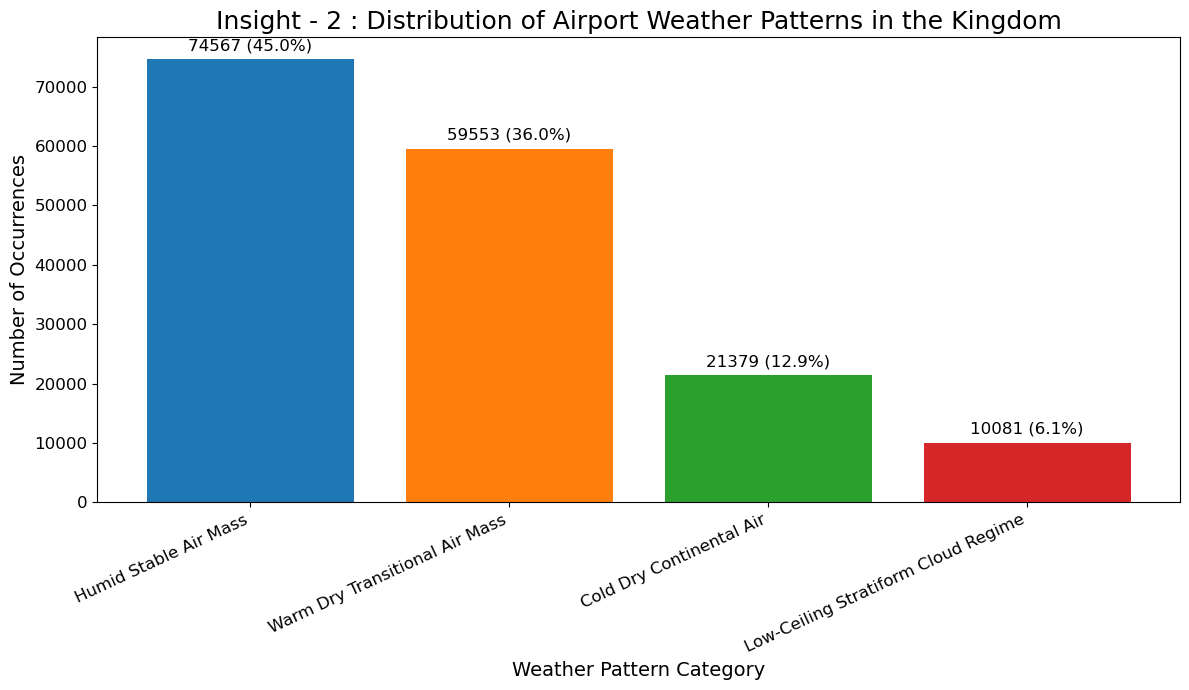

In [107]:
import matplotlib.pyplot as plt

# Data
patterns = [
    "Humid Stable Air Mass",
    "Warm Dry Transitional Air Mass",
    "Cold Dry Continental Air",
    "Low-Ceiling Stratiform Cloud Regime"
]

counts = [74567, 59553, 21379, 10081]

# Compute percentages
total = sum(counts)
percentages = [(c / total) * 100 for c in counts]

plt.figure(figsize=(12, 7))
bars = plt.bar(patterns, counts, color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"])

plt.title("Insight - 2 : Distribution of Airport Weather Patterns in the Kingdom", fontsize=18)
plt.xlabel("Weather Pattern Category", fontsize=14)
plt.ylabel("Number of Occurrences", fontsize=14)

plt.xticks(rotation=25, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Add value + percentage labels above bars
for i, (count, pct) in enumerate(zip(counts, percentages)):
    plt.text(
        i,
        count + 1500,                      # position slightly above bar
        f"{count} ({pct:.1f}%)",           # label: count + percent
        ha='center',
        fontsize=12
    )

plt.tight_layout()
plt.show()


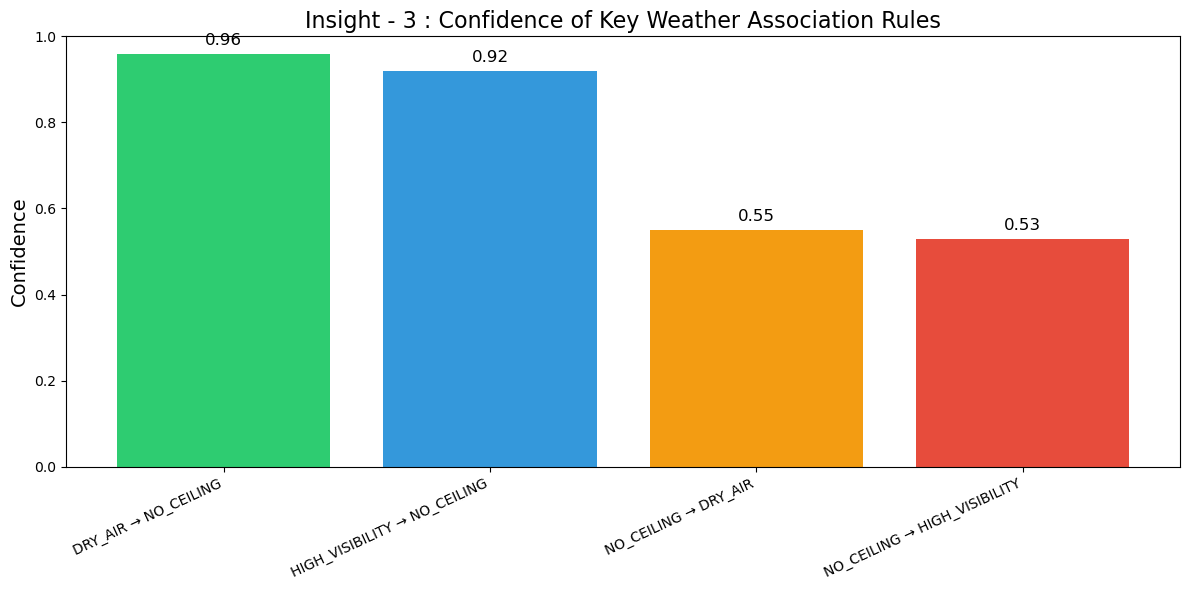

In [108]:
import matplotlib.pyplot as plt

# ======================================================================
# INSIGHTS 2 - Association Rule Confidence
# ======================================================================

rules_labels = [
    "DRY_AIR → NO_CEILING",
    "HIGH_VISIBILITY → NO_CEILING",
    "NO_CEILING → DRY_AIR",
    "NO_CEILING → HIGH_VISIBILITY"
]

confidence = [0.96, 0.92, 0.55, 0.53]   # From your Apriori rules
support =    [0.52, 0.50, 0.52, 0.53]

# 1. Confidence Plot
plt.figure(figsize=(12,6))
plt.bar(rules_labels, confidence, color=["#2ecc71","#3498db","#f39c12","#e74c3c"])
plt.title("Insight - 3 : Confidence of Key Weather Association Rules", fontsize=16)
plt.ylabel("Confidence", fontsize=14)
plt.ylim(0,1)
plt.xticks(rotation=25, ha='right')

for i, c in enumerate(confidence):
    plt.text(i, c+0.02, f"{c:.2f}", ha='center', fontsize=12)

plt.tight_layout()
plt.show()





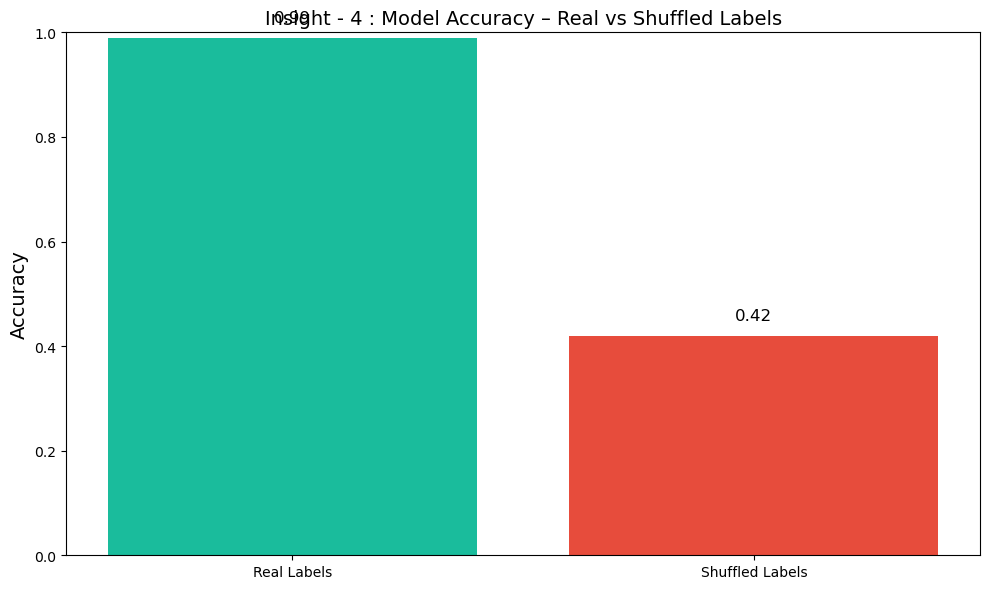

In [109]:

# =======================================================
# INSIGHT 5 — Model Accuracy Before & After Shuffling
# =======================================================

scores = ["Real Labels", "Shuffled Labels"]
accuracy = [0.99, 0.42]

plt.figure(figsize=(10,6))
plt.bar(scores, accuracy, color=["#1abc9c", "#e74c3c"])
plt.title("Insight - 4 : Model Accuracy – Real vs Shuffled Labels", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.ylim(0,1)

for i, a in enumerate(accuracy):
    plt.text(i, a+0.03, f"{a:.2f}", ha='center', fontsize=12)

plt.tight_layout()
plt.show()


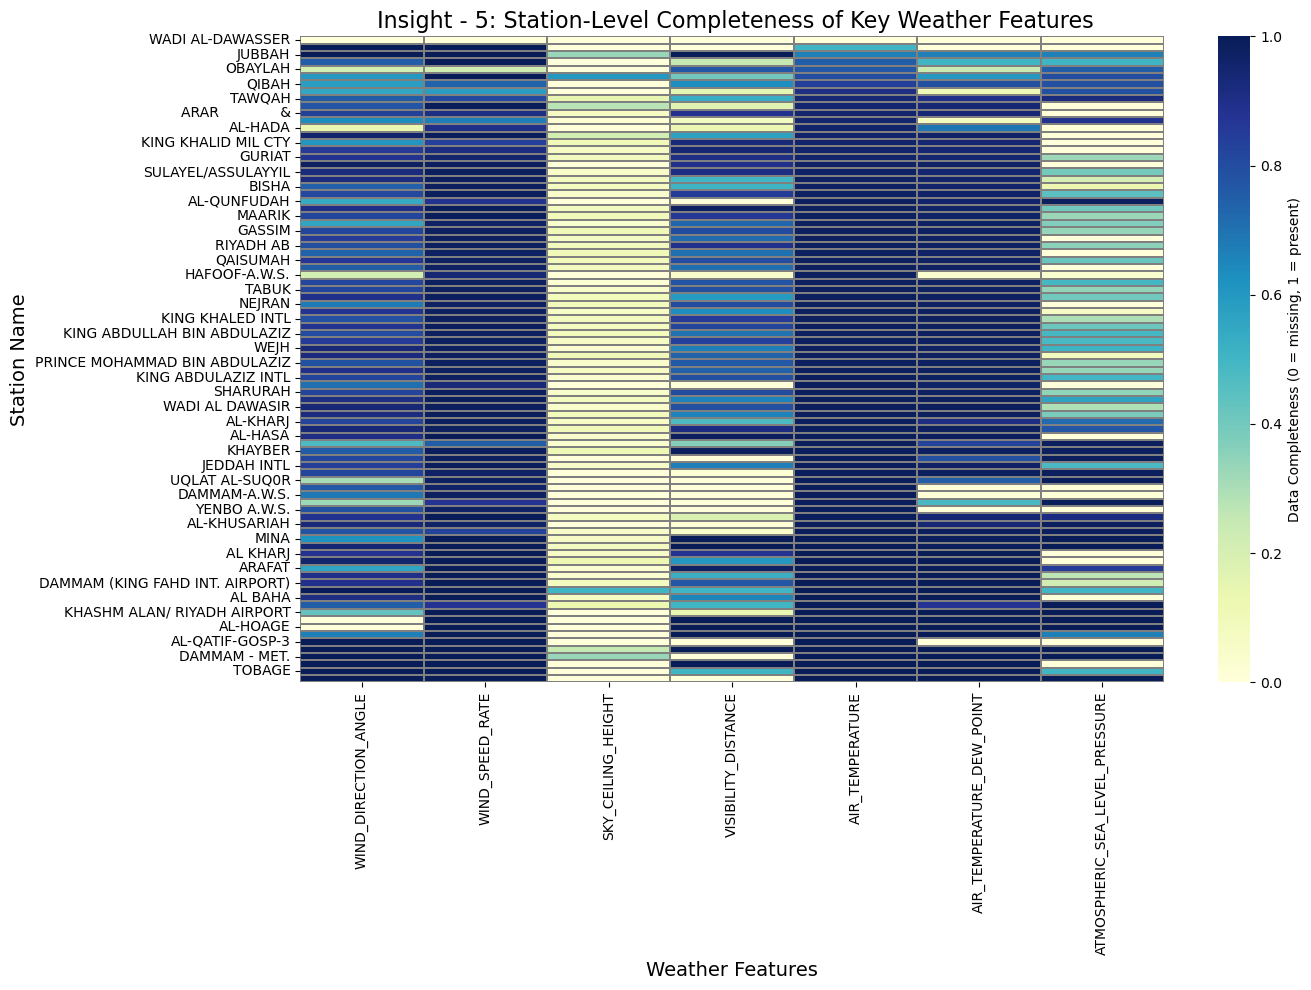

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only important meteorological features
important_features = [
    'WIND_DIRECTION_ANGLE',
    'WIND_SPEED_RATE',
    'SKY_CEILING_HEIGHT',
    'VISIBILITY_DISTANCE',
    'AIR_TEMPERATURE',
    'AIR_TEMPERATURE_DEW_POINT',
    'ATMOSPHERIC_SEA_LEVEL_PRESSURE'
]

# Build missingness matrix per station (1 = present, 0 = missing)
station_feature_matrix = df.groupby('STATION_NAME')[important_features] \
                           .apply(lambda x: x.notna().mean()) \
                           .sort_values(by='AIR_TEMPERATURE')  # Sort for visual clarity

plt.figure(figsize=(14, 10))
sns.heatmap(
    station_feature_matrix,
    cmap="YlGnBu",          # Blue = missing, Yellow/Green = present
    linewidths=0.3,
    linecolor='gray',
    cbar_kws={'label': 'Data Completeness (0 = missing, 1 = present)'}
)

plt.title(" Insight - 5: Station-Level Completeness of Key Weather Features", fontsize=16)
plt.xlabel("Weather Features", fontsize=14)
plt.ylabel("Station Name", fontsize=14)

plt.tight_layout()
plt.show()
